# **Hoja de trabajo #2 - Aprendizaje por Refuerzo**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Monica Salvatierra - 22249
- Bianca Calderón - 22272

Link del repositorio: https://github.com/paulabaal12/HDT2-RL 

---

## **Task 1**

---

Responda las siguientes preguntas de forma clara, concisa y argumentada. No basta con definir, se espera que usted conecte el concepto con sus implicaciones prácticas o estratégicas.

**1. Elijan un sistema real que pueda modelarse como un k-armed bandit. Su modelado debe incluir:**

a). Definición formal de los 𝑘 brazos: qué representa cada acción y por qué el conjunto de
acciones es finito y discreto en este dominio.

b). Diseño justificado de la función de recompensa: qué se mide, cómo se mide, y qué
supuestos distribucionales son razonables para ese dominio. Si la recompensa no es
gaussiana, arguméntenlo.

c). Análisis de estacionariedad: ¿los valores verdaderos 𝑞∗(𝑎) cambian con el tiempo en este sistema? ¿En qué escala temporal? ¿Qué implicaciones tiene eso para el algoritmo de
actualización?

d). Identificación de restricciones de exploración: ¿hay costos económicos, de seguridad o
regulatorios que limiten cuánto puede explorar el sistema?

---

**Sistema propuesto: Precio dinámico en máquinas expendedoras inteligentes**

Cada vez más máquinas expendedoras tienen pantallas digitales y conectividad, lo que permite cambiar el precio de un producto en tiempo real (no como las de antes, con precio fijo impreso). Es un ejemplo real usado por empresas como Coca-Cola y algunas startups de "smart vending".



**a) Definición formal de los k brazos**

Cada brazo `a` representa un precio distinto al que se puede ofrecer un producto específico (ej. una lata de soda) en un momento dado. Por ejemplo, con k = 5:

a₁: Q. 12.00
a₂: Q. 15.00
a₃: Q. 18.00
a₄: Q. 20.00
a₅: Q. 25.00

El conjunto de acciones es finito y discreto porque:

1. La pantalla/sistema de cobro solo admite ciertos incrementos de precio (normalmente múltiplos de Q 0.50 o Q. 1.00, no cualquier valor continuo).

2. Cambiar de precio tiene que pasar por aprobación del operador de la máquina (o de la marca dueña del producto), quienes típicamente autorizan un catálogo cerrado de precios "permitidos" por razones de imagen de marca y percepción del consumidor.

3. Psicológicamente los precios funcionan por anclas discretas (terminaciones en 0, 5, 9), así que en la práctica el negocio nunca probaría un continuo de precios sino un conjunto de opciones "razonables".

**b) Diseño de la función de recompensa**

- Qué se mide: ingreso neto por transacción potencial (ventas × precio), no solo unidades vendidas.

- Cómo se mide: el sistema de pago de la máquina registra cada intento de compra. Si el cliente completó la compra al precio mostrado, o si "abandonó" (miró el precio y no compró). Con eso se calcula:

`R(a) = precio(a)` si hubo compra, 0 si no hubo compra


Supuestos distribucionales:

En este caso, la recompensa no es gaussiana, esto se debe a que cada evento (una persona parada frente a la máquina) es una decisión binaria. Ya sea compra o no compra a ese precio. Eso es un ensayo Bernoulli con probabilidad p(a) que depende del precio.

La recompensa observada entonces es 0 o precio(a), una distribución discreta de dos puntos, no continua ni simétrica, así que claramente no es gaussiana.

Además, se espera que p(a) sea decreciente en el precio (curva de demanda), lo que hace que el valor esperado q*(a) = precio(a)·p(a) tenga una forma tipo joroba (sube y luego baja) en vez de ser monótono.

**c) Análisis de estacionariedad**

Los valores verdaderos q*(a) sí cambian con el tiempo, en varias escalas:

- Diaria/a cada hora: En oficinas o universidades, la disposición a pagar cambia entre mañana (gente con prisa, más inelástica) y tarde (gente más sensible al precio).

- Semanal: Fin de quincena/quincena de pago vs. días previos a la nómina. La elasticidad de precio de los clientes cambia según cuánto efectivo/saldo disponible tengan.

- Estacional: En época de calor sube la disposición a pagar por una bebida fría (demanda más inelástica); en época fría baja.

- Competencia externa: si abre una tienda de conveniencia cerca, o cambia el precio en la tienda de al lado, la elasticidad de la máquina cambia de forma persistente.

**Implicación para el algoritmo:** Suponer un promedio muestral simple (con peso 1/n) no es adecuado aquí, ya que le resta importancia a las observaciones más recientes. Por eso conviene:

- Usar actualización con paso constante α para dar más peso a transacciones recientes.
- Usar un bandit contextual, donde el contexto es hora del día / día de la semana / temporada, en lugar de tratar el problema como un solo bandit estacionario.
- Considerar métodos con detección de cambio para reaccionar rápido si aparece competencia nueva.

**d) Restricciones de exploración**

- **Económicas directas:** Explorar un precio muy bajo (a₁) implica perder margen real en cada venta durante la exploración. Por otro lado, explorar uno muy alto (a₅) implica perder ventas (y quizás enojar clientes) mientras se recopila información.

- **Regulatorias:** La marca dueña del producto (ej. Coca-Cola) suele fijar un rango de precio "sugerido" o incluso un precio máximo permitido contractualmente, limitando el conjunto de brazos que se pueden probar libremente.

- **Reputacionales:** Si los clientes notan que el precio "cambia todo el tiempo" o que es más caro en ciertos horarios, puede dañar la confianza y reducir ventas futuras de forma persistente. Un costo de exploración que no se recupera fácilmente aunque luego se baje el precio de nuevo.

- **Volumen de datos:** Una sola máquina puede tener pocas transacciones al día (quizás 20-50), así que el "presupuesto de exploración" es limitado. No se puede alcanzar significancia estadística rápido, lo que justifica utilizar máquinas múltiples (varias ubicaciones) como réplicas del mismo experimento para acelerar el aprendizaje.

**2. Con base en el análisis anterior, propongan y justifiquen:**

a). La estrategia de selección de acción más apropiada para su dominio, con el valor concreto del hiperparámetro relevante (𝜀 o 𝑐) y la justificación de ese valor  

b). La regla de actualización de estimaciones (paso variable o constante) con justificación ligada al análisis de estacionariedad, y  

c). Un ejemplo numérico con al menos seis observaciones que ilustre cómo evoluciona 𝑄𝑡(𝑎)para dos acciones distintas bajo la regla elegida, mostrando cómo la estimación converge o se adapta.

---

**a) La estrategia de selección de acción más apropiada para su dominio, con el valor concreto del hiperparámetro relevante (𝜀 o 𝑐) y la justificación de ese valor**

``
ε = 0.1
``  
  
  
**Justificacion:**  
Se eligio un valor 0.1 el cual es considerablemente grande, mas que todo porque nuestra exploración significa un costo real.
Si se prueba un precio muy bajao, se pierde margen de ganancia
Si se prueba muy alto, disminuye las ventas y puede afectar la percepcion del cliente.
Por eso no conviene explorar tanto pero tampoco significa que no vamos a explorar, debido a que la demanda cambia con la logica 

**b). La regla de actualización de estimaciones (paso variable o constante) con justificación ligada al análisis de estacionariedad**  
  
El problema es no estacionario, se utiliza un actualizacion de paso constante

$Q_{t+1}(a) = Q_t(a) + \alpha(R_t-Q_t(a))$.  
  
Se utilizaria $\alpha$ = 0.2 el cual serua un paso constante, las trasacciones recientes tienen mayor influencia, el sistema se puede adaptar rapido cuando cambia el comportamiento de compra y se mantiene estabilidad en cada observación.



**c). ejemplo**    
  
para dos precios: 
a1 = Q12
a2 = Q20  
  
se empieza con  
$Q_0(a_1)=0$
$Q_0(a_2)=0$
  
  
Si se compra se obtiene una recompensa del precio y si no se compra es 0  

T = 0  
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_1$ | 12 | 0 + 0.2 (12-0) = 2.4 | 0 |  

T = 1
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_2$ | 0 | 2.4 | 0 |

T = 2
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_1$ | 12 | 2.4 + 0.2(12-24) = 4.32 | 0 |

T = 3
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_1$ | 12 | 2.4 + 0.2(12-24) = 4.32 | 0 |

T = 4
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_2$ | 20 | 4.32 | 0 + 0.2(20-0) = 4.00 |

T = 5
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_1$ | 0 | 4.32 + 0.2(0-4.32) = 3.456 | 4.00 |

T = 5
| Acción | Recompensa | $Q(a_1)$ | $Q(a_2)$ |  
|--------|--------|------|------|  
| $a_2$ | 20 | 3.456 | 4.00 + 0.2(20-4) = 7.2 |

---

## **Task 2**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

K        = 10     
EPISODES = 500   
STEPS    = 1000 
SEED     = 2026

plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
class KArmedBandit:
    def __init__(self, k=10, stationary=True, drift_every=100, drift_std=0.5, rng=None):
        self.k = k
        self.stationary = stationary
        self.drift_every = drift_every  
        self.drift_std = drift_std      
        self.rng = rng if rng is not None else np.random.default_rng()

        # q*(a) ~ N(0,1) : valores verdaderos, desconocidos para el agente
        self.q_star = self.rng.normal(0.0, 1.0, size=k)
        self.t = 0

    def step(self, action):
        self.t += 1

        # R_t ~ N(q*(a), 1)  ->  E[R_t | A_t=a] = q*(a)
        reward = self.rng.normal(self.q_star[action], 1.0)
        regret = self.q_star.max() - self.q_star[action]
        if (not self.stationary) and (self.t % self.drift_every == 0):
            self.q_star = self.q_star + self.rng.normal(0.0, self.drift_std, size=self.k)

        return reward, regret

    def optimal_action(self):
        return int(np.argmax(self.q_star))

#### Clases de estrategias

In [3]:
class BanditAgent:
    """mantiene Q(a) y N(a), e implementa la regla incremental."""

    def __init__(self, k, alpha=None, Q0=0.0):
        self.k = k
        self.alpha = alpha        
        self.Q0 = Q0
        self.reset()

    def reset(self):
        self.Q = np.full(self.k, float(self.Q0), dtype=float)  # Q_1(a) = Q_0
        self.N = np.zeros(self.k, dtype=int)                   # N_t(a)
        self.t = 0

    def select_action(self, rng):
        raise NotImplementedError

    def update(self, action, reward):
        """Q_{n+1} = Q_n + alpha * (R_n - Q_n)"""
        self.N[action] += 1
        step = self.alpha if self.alpha is not None else 1.0 / self.N[action]
        self.Q[action] += step * (reward - self.Q[action])

    @staticmethod
    def _argmax_random_tie(values, rng):
        best = np.flatnonzero(values == values.max())
        return int(rng.choice(best))

In [4]:
class GreedyAgent(BanditAgent):
    name = "Greedy puro"

    def select_action(self, rng):
        self.t += 1
        return self._argmax_random_tie(self.Q, rng)


class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, k, epsilon=0.1, **kwargs):
        super().__init__(k, **kwargs)
        self.epsilon = epsilon
        self.name = f"eps-greedy (eps={epsilon})"

    def select_action(self, rng):
        self.t += 1
        if rng.random() < self.epsilon:
            return int(rng.integers(self.k))            # exploración uniforme
        return self._argmax_random_tie(self.Q, rng)     # explotación


class UCB1Agent(BanditAgent):
    def __init__(self, k, c=2.0, **kwargs):
        super().__init__(k, **kwargs)
        self.c = c
        self.name = f"UCB1 (c={c})"

    def select_action(self, rng):
        self.t += 1
        never_tried = np.flatnonzero(self.N == 0)
        if never_tried.size > 0:
            return int(rng.choice(never_tried))

        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return self._argmax_random_tie(ucb, rng)

#### Loop de experimento

In [5]:
def run_experiment(agent_factory, episodes=EPISODES, steps=STEPS,
                   stationary=True, k=K, seed=SEED, drift_every=100, drift_std=0.5):
    rewards = np.zeros(steps)
    cum_regret = np.zeros(steps)

    for e in range(episodes):
        rng = np.random.default_rng(seed * 100_000 + e)   # reproducible por episodio
        env = KArmedBandit(k=k, stationary=stationary, rng=rng,
                           drift_every=drift_every, drift_std=drift_std)
        agent = agent_factory(k)

        running = 0.0
        for t in range(steps):
            a = agent.select_action(rng)
            r, l = env.step(a)
            agent.update(a, r)

            rewards[t] += r
            running += l                 # L_t = suma de l_s hasta t
            cum_regret[t] += running

    return rewards / episodes, cum_regret / episodes


def plot_pair(results, titulo):
    """Grafica recompensa promedio y regret acumulado"""
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    for label, (R, L) in results.items():
        ax[0].plot(R, label=label, lw=1.2)
        ax[1].plot(L, label=label, lw=1.6)
    ax[0].set_title(f"Recompensa promedio por paso — {titulo}")
    ax[0].set_xlabel("Paso t"); ax[0].set_ylabel(r"$\bar{R}_t$"); ax[0].legend()
    ax[1].set_title(f"Regret acumulado — {titulo}")
    ax[1].set_xlabel("Paso t"); ax[1].set_ylabel(r"$L_T$"); ax[1].legend()
    plt.tight_layout(); plt.show()

#### Entorno estacionario (paso variable $1/n$)

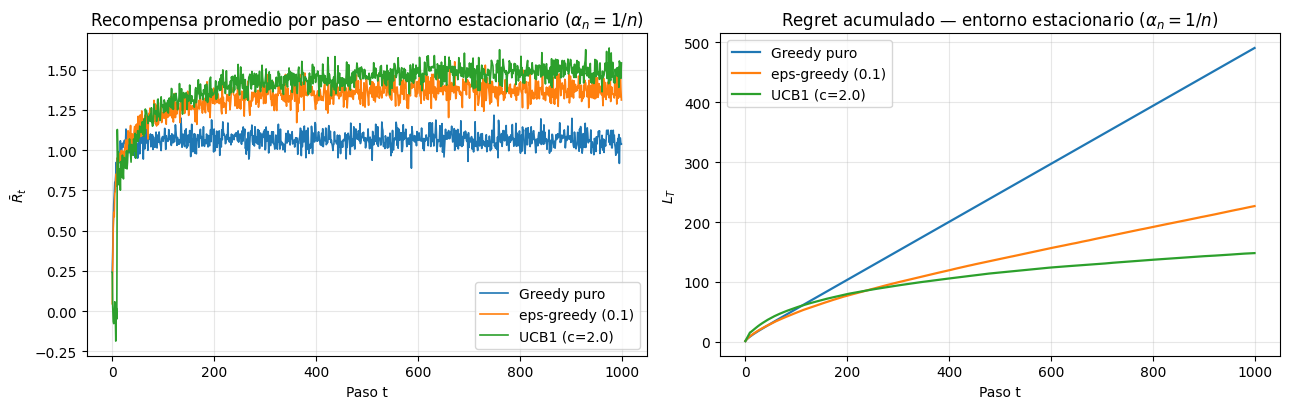

Regret acumulado final (T=1000):
  Greedy puro            L_T =   490.5   |  R promedio ult. 100 pasos = 1.058
  eps-greedy (0.1)       L_T =   226.7   |  R promedio ult. 100 pasos = 1.375
  UCB1 (c=2.0)           L_T =   148.2   |  R promedio ult. 100 pasos = 1.490


In [6]:
EPS = 0.1
C   = 2.0

fabricas_estacionario = {
    "Greedy puro":         lambda k: GreedyAgent(k, alpha=None),
    f"eps-greedy ({EPS})": lambda k: EpsilonGreedyAgent(k, epsilon=EPS, alpha=None),
    f"UCB1 (c={C})":       lambda k: UCB1Agent(k, c=C, alpha=None),
}

res_estacionario = {name: run_experiment(f, stationary=True)
                    for name, f in fabricas_estacionario.items()}

plot_pair(res_estacionario, "entorno estacionario ($\\alpha_n = 1/n$)")

print("Regret acumulado final (T=1000):")
for name, (R, L) in res_estacionario.items():
    print(f"  {name:22s} L_T = {L[-1]:7.1f}   |  R promedio ult. 100 pasos = {R[-100:].mean():.3f}")

#### Entorno no estacionario

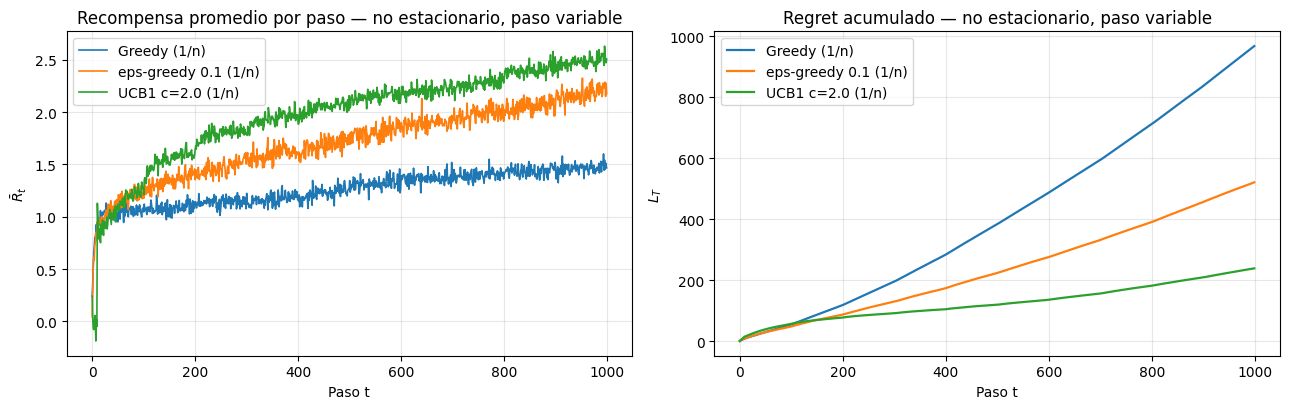

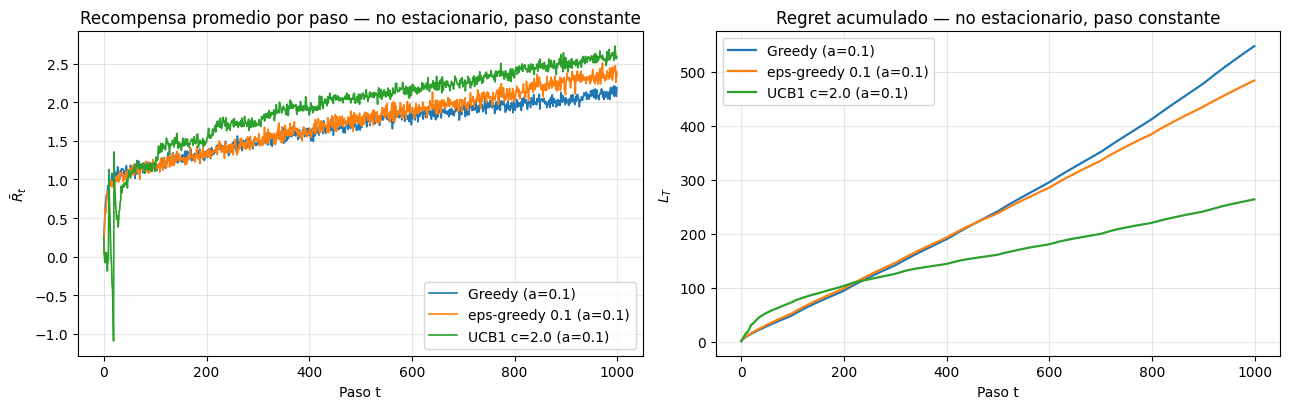

Regret acumulado final (T=1000), entorno no estacionario:

  -- paso variable 1/n --
     Greedy (1/n)                     L_T =   967.3  |  R ult.100 = 1.462
     eps-greedy 0.1 (1/n)             L_T =   520.9  |  R ult.100 = 2.172
     UCB1 c=2.0 (1/n)                 L_T =   239.3  |  R ult.100 = 2.479

  -- paso constante a=0.1 --
     Greedy (a=0.1)                   L_T =   547.1  |  R ult.100 = 2.080
     eps-greedy 0.1 (a=0.1)           L_T =   483.5  |  R ult.100 = 2.326
     UCB1 c=2.0 (a=0.1)               L_T =   263.5  |  R ult.100 = 2.553


In [7]:
ALPHA_CONST = 0.1

fabricas_ns_variable = {
    "Greedy (1/n)":            lambda k: GreedyAgent(k, alpha=None),
    f"eps-greedy {EPS} (1/n)": lambda k: EpsilonGreedyAgent(k, epsilon=EPS, alpha=None),
    f"UCB1 c={C} (1/n)":       lambda k: UCB1Agent(k, c=C, alpha=None),
}

fabricas_ns_constante = {
    f"Greedy (a={ALPHA_CONST})":            lambda k: GreedyAgent(k, alpha=ALPHA_CONST),
    f"eps-greedy {EPS} (a={ALPHA_CONST})":  lambda k: EpsilonGreedyAgent(k, epsilon=EPS, alpha=ALPHA_CONST),
    f"UCB1 c={C} (a={ALPHA_CONST})":        lambda k: UCB1Agent(k, c=C, alpha=ALPHA_CONST),
}

res_ns_var  = {n: run_experiment(f, stationary=False) for n, f in fabricas_ns_variable.items()}
res_ns_cte  = {n: run_experiment(f, stationary=False) for n, f in fabricas_ns_constante.items()}

plot_pair(res_ns_var, "no estacionario, paso variable")
plot_pair(res_ns_cte, "no estacionario, paso constante")

print("Regret acumulado final (T=1000), entorno no estacionario:")
for etiqueta, res in [("paso variable 1/n", res_ns_var), (f"paso constante a={ALPHA_CONST}", res_ns_cte)]:
    print(f"\n  -- {etiqueta} --")
    for name, (R, L) in res.items():
        print(f"     {name:32s} L_T = {L[-1]:7.1f}  |  R ult.100 = {R[-100:].mean():.3f}")

#### Comparación directa paso variable vs. paso constante

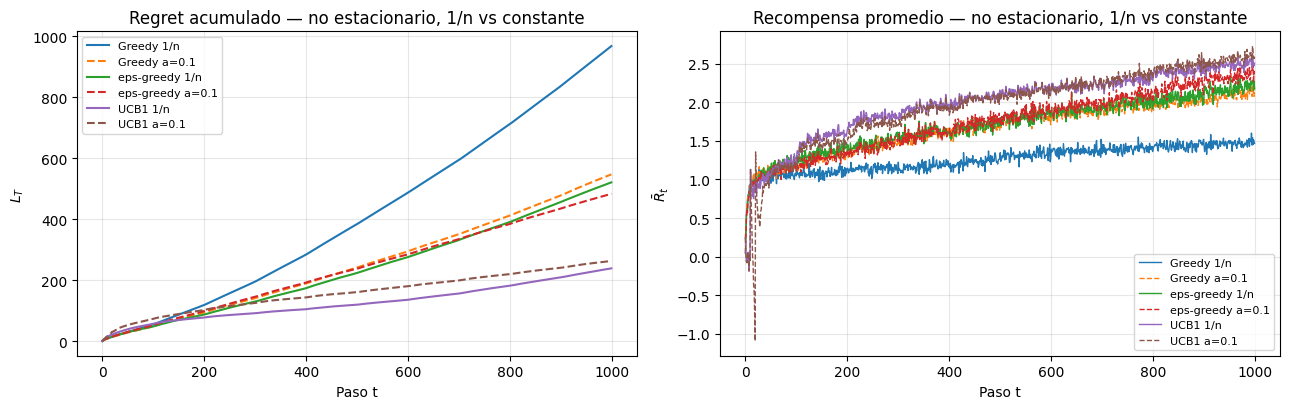

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
pares = [("Greedy", "Greedy (1/n)", f"Greedy (a={ALPHA_CONST})"),
         ("eps-greedy", f"eps-greedy {EPS} (1/n)", f"eps-greedy {EPS} (a={ALPHA_CONST})"),
         ("UCB1", f"UCB1 c={C} (1/n)", f"UCB1 c={C} (a={ALPHA_CONST})")]

for base, kv, kc in pares:
    ax[0].plot(res_ns_var[kv][1], lw=1.5, label=f"{base} 1/n")
    ax[0].plot(res_ns_cte[kc][1], lw=1.5, ls="--", label=f"{base} a={ALPHA_CONST}")
    ax[1].plot(res_ns_var[kv][0], lw=1.0, label=f"{base} 1/n")
    ax[1].plot(res_ns_cte[kc][0], lw=1.0, ls="--", label=f"{base} a={ALPHA_CONST}")

ax[0].set_title("Regret acumulado — no estacionario, 1/n vs constante")
ax[0].set_xlabel("Paso t"); ax[0].set_ylabel("$L_T$"); ax[0].legend(fontsize=8)
ax[1].set_title("Recompensa promedio — no estacionario, 1/n vs constante")
ax[1].set_xlabel("Paso t"); ax[1].set_ylabel(r"$\bar{R}_t$"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Análisis de sensibilidad de hiperparámetros

In [ ]:
EPS_GRID = [0.01, 0.05, 0.1, 0.2, 0.3]
C_GRID   = [0.25, 0.5, 1.0, 2.0, 4.0]

sens_eps_stat, sens_c_stat, sens_eps_ns, sens_c_ns = [], [], [], []

for e in EPS_GRID:
    _, L = run_experiment(lambda k, e=e: EpsilonGreedyAgent(k, epsilon=e, alpha=None), stationary=True)
    sens_eps_stat.append(L[-1])
    _, L = run_experiment(lambda k, e=e: EpsilonGreedyAgent(k, epsilon=e, alpha=ALPHA_CONST), stationary=False)
    sens_eps_ns.append(L[-1])

for cc in C_GRID:
    _, L = run_experiment(lambda k, cc=cc: UCB1Agent(k, c=cc, alpha=None), stationary=True)
    sens_c_stat.append(L[-1])
    _, L = run_experiment(lambda k, cc=cc: UCB1Agent(k, c=cc, alpha=ALPHA_CONST), stationary=False)
    sens_c_ns.append(L[-1])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(EPS_GRID, sens_eps_stat, "o-", label="estacionario (1/n)")
ax[0].plot(EPS_GRID, sens_eps_ns,  "s--", label=f"no estacionario (a={ALPHA_CONST})")
ax[0].set_xlabel(r"$\varepsilon$"); ax[0].set_ylabel("$L_{1000}$")
ax[0].set_title(r"Regret final vs $\varepsilon$"); ax[0].legend()

ax[1].plot(C_GRID, sens_c_stat, "o-", label="estacionario (1/n)")
ax[1].plot(C_GRID, sens_c_ns,  "s--", label=f"no estacionario (a={ALPHA_CONST})")
ax[1].set_xlabel("$c$"); ax[1].set_ylabel("$L_{1000}$")
ax[1].set_title("Regret final vs $c$"); ax[1].legend()
plt.tight_layout(); plt.show()

print("eps :", [(e, round(v,1)) for e, v in zip(EPS_GRID, sens_eps_stat)])
print("c   :", [(cc, round(v,1)) for cc, v in zip(C_GRID, sens_c_stat)])

In [ ]:
_, L_ucb = run_experiment(lambda k: UCB1Agent(k, c=C, alpha=None), stationary=True)
_, L_eps = run_experiment(lambda k: EpsilonGreedyAgent(k, epsilon=EPS, alpha=None), stationary=True)
dif = L_ucb - L_eps
cruce = next((t for t in range(50, STEPS) if np.all(dif[t:] < 0)), None)
print("UCB queda permanentemente por debajo de eps-greedy a partir del paso:", cruce)
plt.figure(figsize=(7, 4))
plt.plot(dif); plt.axhline(0, color="k", lw=0.8)
if cruce: plt.axvline(cruce, color="r", ls="--", label=f"cruce ~ t={cruce}")
plt.title(r"$L_t^{UCB} - L_t^{\varepsilon-greedy}$ (estacionario)")
plt.xlabel("Paso t")
if cruce: plt.legend()
plt.tight_layout(); plt.show()

## **Prompt Utilizado**

Uso de IA generativa: Pedimos orientación de código para el Task 2, específicamente sobre cómo estructurar el simulador en clases (`KArmedBandit`, y una clase por estrategia con `select_action` y `update`) y cómo implementar la regla incremental de forma que soportara tanto paso variable (1/n) como paso constante (α) sin duplicar lógica. También consultamos cómo calcular correctamente el regret acumulado promediado sobre los 500 episodios.

### Por qué funcionó este prompt
- Fuimos explícitos con las fórmulas de las diapositivas (Q_{n+1} = Q_n + α(R_n − Q_n) y el bono de UCB1), así que el código generado quedó trazable contra la teoría vista en clase y no usó variantes distintas.
- Aclaramos que no queríamos resultados numéricos inventados, sino ejecutar primero y escribir el análisis después lo cual nos obligó a sustentar cada conclusión con las corridas reales.